# Soft Time Windows

In the basic VRPTW model, each customer's time window is a **hard constraint**: arriving outside `[a, b]` is impossible. Real life is messier:

- A grocery delivery 10 minutes late is annoying. 2 hours late triggers a refund. *Neither* is impossible.
- A patient pickup 20 minutes early forces the carer to wait. Acceptable; not free.
- Some windows are *requested* by the customer, but the SLA only really binds at the daily cutoff.

**Soft time windows** model exactly this: instead of forbidding arrival outside the window, you pay a *penalty per minute* of earliness or lateness. The penalty goes into the objective alongside distance, and the solver trades off distance against time-window violations.

## What's new in the OR-Tools API

Two methods on the time dimension:

```python
time_dim.SetCumulVarSoftLowerBound(node_idx, a, early_penalty_per_unit)
time_dim.SetCumulVarSoftUpperBound(node_idx, b, late_penalty_per_unit)
```

These add `coef * max(0, lower_bound - cumul)` (for early) and `coef * max(0, cumul - upper_bound)` (for late) to the objective. The CumulVar still needs *some* hard upper bound (the working-day horizon) so the model is well-defined.

**Units gotcha:** `coef` is the penalty per *unit* of the time dimension (typically per minute). If distance is in km and time in minutes, `coef=1` means "1 km of distance is worth avoiding 1 minute of lateness." Picking the right coefficient is a modelling choice — too low and the solver ignores windows entirely, too high and soft is indistinguishable from hard.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

random.seed(101)
np.random.seed(101)

## 1. A deliberately tight instance

We pick a 10-customer instance where the windows are *tight enough that the hard-window solver leans on every minute*. That way the difference between hard and soft is visible — with loose windows, soft and hard produce nearly identical results.

- 10 customers in a 50×50 km area, depot at the centre.
- 60-minute windows spread through a 480-minute day.
- 5-minute service time, vehicle capacity 25, 3 vehicles.
- Travel speed: 1 km/min.

In [2]:
N_CUSTOMERS = 10
DEPOT = 0
HORIZON = 480
SERVICE_TIME = 5
NUM_VEHICLES = 3
VEHICLE_CAPACITY = 25
WINDOW_WIDTH = 60

points = [(25.0, 25.0)] + [
    (random.uniform(0, 50), random.uniform(0, 50)) for _ in range(N_CUSTOMERS)
]
demands = [0] + [random.randint(2, 8) for _ in range(N_CUSTOMERS)]

def make_int_distance(pts):
    n = len(pts)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i != j:
                m[i][j] = int(round(math.hypot(xi - xj, yi - yj)))
    return m

distance = make_int_distance(points)

windows = [(0, HORIZON)]
for _ in range(N_CUSTOMERS):
    start = random.randint(30, HORIZON - WINDOW_WIDTH - 30)
    windows.append((start, start + WINDOW_WIDTH))

print(f"{N_CUSTOMERS} customers, total demand {sum(demands)} (fleet capacity {NUM_VEHICLES * VEHICLE_CAPACITY})")
for i in range(1, len(points)):
    print(f"  c{i}: pos=({points[i][0]:5.1f},{points[i][1]:5.1f})  demand={demands[i]}  window=[{windows[i][0]},{windows[i][1]}]")

10 customers, total demand 41 (fleet capacity 75)
  c1: pos=( 29.1,  9.7)  demand=5  window=[349,409]
  c2: pos=( 48.3, 46.2)  demand=5  window=[378,438]
  c3: pos=( 23.4, 33.2)  demand=3  window=[198,258]
  c4: pos=( 10.7, 11.1)  demand=2  window=[370,430]
  c5: pos=( 14.4, 34.6)  demand=5  window=[166,226]
  c6: pos=( 10.6, 48.6)  demand=5  window=[232,292]
  c7: pos=(  3.5,  9.7)  demand=4  window=[224,284]
  c8: pos=(  4.4, 38.5)  demand=3  window=[147,207]
  c9: pos=( 18.3, 23.6)  demand=2  window=[246,306]
  c10: pos=( 16.3, 31.9)  demand=7  window=[69,129]


## 2. One model builder, two modes

We'll write a single `build_vrptw` that accepts an `early_penalty` and `late_penalty`. When both are `None`, windows are hard (the original behaviour). When either is set, the corresponding bound becomes soft.

Note that *even when soft*, we still set a hard `SetRange(0, horizon)` so the CumulVar is bounded. Otherwise the solver would have no upper bound and the model wouldn't be well-formed.

In [3]:
def build_vrptw(
    distance, demands, time_windows, capacities,
    service_time, horizon, depot=0, wait_slack=60,
    early_penalty=None, late_penalty=None,
):
    n = len(distance)
    num_vehicles = len(capacities)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    def distance_cb(fi, ti):
        return distance[manager.IndexToNode(fi)][manager.IndexToNode(ti)]
    transit_idx = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, list(capacities), True, "Capacity",
    )

    def time_cb(fi, ti):
        from_node = manager.IndexToNode(fi)
        to_node = manager.IndexToNode(ti)
        st = 0 if from_node == depot else service_time
        return st + distance[from_node][to_node]
    time_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_idx, wait_slack, horizon, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")

    soft = early_penalty is not None or late_penalty is not None

    for node in range(n):
        if node == depot:
            continue
        a, b = time_windows[node]
        idx = manager.NodeToIndex(node)
        if soft:
            time_dim.CumulVar(idx).SetRange(0, horizon)
            if early_penalty is not None:
                time_dim.SetCumulVarSoftLowerBound(idx, int(a), int(early_penalty))
            if late_penalty is not None:
                time_dim.SetCumulVarSoftUpperBound(idx, int(b), int(late_penalty))
        else:
            time_dim.CumulVar(idx).SetRange(int(a), int(b))

    depot_open, depot_close = time_windows[depot]
    for v in range(num_vehicles):
        time_dim.CumulVar(routing.Start(v)).SetRange(int(depot_open), int(depot_close))
        time_dim.CumulVar(routing.End(v)).SetRange(int(depot_open), int(depot_close))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.Start(v)))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.End(v)))

    return manager, routing, time_dim


def solve(routing, time_limit=5):
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)
    return routing.SolveWithParameters(params)

## 3. Solve and decompose the objective

With soft windows, the objective the solver reports is `total_distance + sum_of_penalties`. To understand what the solver actually traded, we need to *separate* the two — re-walk the routes, compute the pure distance, and from the schedule compute how much earliness/lateness each customer absorbed.

In [4]:
def solve_and_decompose(early_penalty=None, late_penalty=None, time_limit=5):
    mgr, rt, tdim = build_vrptw(
        distance, demands, windows,
        capacities=[VEHICLE_CAPACITY] * NUM_VEHICLES,
        service_time=SERVICE_TIME, horizon=HORIZON,
        early_penalty=early_penalty, late_penalty=late_penalty,
    )
    sol = solve(rt, time_limit=time_limit)
    if sol is None:
        return {"status": rt.status(), "distance": None, "early": None,
                "late": None, "obj": None, "routes": [], "arrivals": {}}

    routes = []
    arrivals = {}
    total_distance = 0
    for v in range(NUM_VEHICLES):
        idx = rt.Start(v)
        route = []
        while not rt.IsEnd(idx):
            node = mgr.IndexToNode(idx)
            route.append(node)
            arrivals[node] = sol.Min(tdim.CumulVar(idx))
            prev = idx
            idx = sol.Value(rt.NextVar(idx))
            total_distance += rt.GetArcCostForVehicle(prev, idx, v)
        route.append(mgr.IndexToNode(idx))
        routes.append(route)

    early_total = 0
    late_total = 0
    for node in range(1, len(distance)):
        if node not in arrivals:
            continue
        arr = arrivals[node]
        a, b = windows[node]
        if arr < a:
            early_total += a - arr
        elif arr > b:
            late_total += arr - b

    return {
        "status": rt.status(),
        "distance": total_distance,
        "early_min": early_total,
        "late_min": late_total,
        "obj": sol.ObjectiveValue(),
        "routes": routes,
        "arrivals": arrivals,
    }

hard = solve_and_decompose()
print("Hard windows:")
print(f"  status:      {hard['status']}")
print(f"  distance:    {hard['distance']} km")
print(f"  early:       {hard['early_min']} min (always 0 with hard windows)")
print(f"  late:        {hard['late_min']} min (always 0 with hard windows)")

Hard windows:
  status:      1
  distance:    209 km
  early:       0 min (always 0 with hard windows)
  late:        0 min (always 0 with hard windows)


## 4. Sweeping the penalty coefficient

Now switch on both `early_penalty` and `late_penalty` (symmetric for now). We'll sweep them together from 0 to large and watch the trade-off between distance and total time-window violation.

**Heads up — a subtlety:** if you set only `late_penalty` (no `early_penalty`), the solver can arrive *earlier* than the window opens *for free*, and that can produce a shorter tour than the hard-window baseline (waiting inside a window costs slack, arriving early costs nothing). That's a different experiment — we're skipping it here in favour of the symmetric case where both kinds of violation cost.

**Expected pattern:**

- `penalty = 0`: solver ignores windows entirely → minimal distance, maximal lateness/earliness.
- Small `penalty`: solver tightens up, still some violations.
- Large `penalty`: solver behaves like the hard-window solver. Distance approaches the hard baseline; violations vanish.

In [5]:
rows = []
for p in [0, 1, 5, 20, 100, 1000]:
    r = solve_and_decompose(early_penalty=p, late_penalty=p)
    rows.append({
        "penalty": p,
        "status": r["status"],
        "distance_km": r["distance"],
        "early_min": r["early_min"],
        "late_min": r["late_min"],
        "violation_total": r["early_min"] + r["late_min"],
        "objective": r["obj"],
    })
sweep_df = pd.DataFrame(rows)
sweep_df

,penalty,status,distance_km,early_min,late_min,violation_total,objective
0,0,1,186,1941,0,1941,186
1,1,1,186,14,0,14,200
2,5,1,209,0,0,0,209
3,20,1,209,0,0,0,209
4,100,1,209,0,0,0,209
5,1000,1,209,0,0,0,209


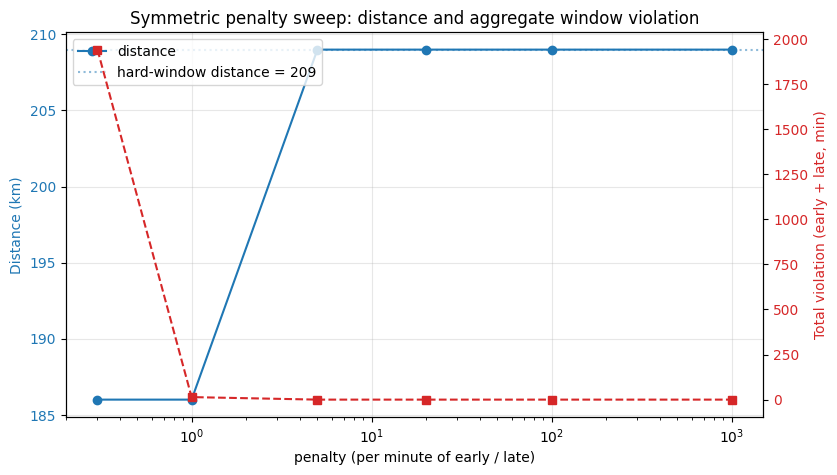

In [6]:
fig, ax1 = plt.subplots(figsize=(9, 5))
c1, c2 = "tab:blue", "tab:red"
df = sweep_df.copy()
df["x"] = df["penalty"].replace(0, 0.3)  # for log scale
ax1.plot(df["x"], df["distance_km"], "o-", color=c1, label="distance")
ax1.axhline(hard["distance"], linestyle=":", color=c1, alpha=0.5,
            label=f"hard-window distance = {hard['distance']}")
ax1.set_xlabel("penalty (per minute of early / late)")
ax1.set_ylabel("Distance (km)", color=c1)
ax1.tick_params(axis="y", labelcolor=c1)
ax1.set_xscale("log")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df["x"], df["violation_total"], "s--", color=c2, label="total violation")
ax2.set_ylabel("Total violation (early + late, min)", color=c2)
ax2.tick_params(axis="y", labelcolor=c2)

plt.title("Symmetric penalty sweep: distance and aggregate window violation")
plt.show()

## 5. Asymmetric early/late penalties

In many domains, *early* and *late* are not symmetric. A grocery delivery 30 minutes early might just mean a wasted stop (driver waits); 30 minutes late is a customer complaint. We can model that by setting `early_penalty < late_penalty`.

In [7]:
scenarios = {
    "early-tolerant (e=1, l=20)":   (1, 20),
    "symmetric (e=10, l=10)":       (10, 10),
    "late-tolerant (e=20, l=1)":    (20, 1),
}
rows = []
for name, (e, l) in scenarios.items():
    r = solve_and_decompose(early_penalty=e, late_penalty=l)
    rows.append({
        "scenario": name,
        "distance": r["distance"],
        "early_min": r["early_min"],
        "late_min": r["late_min"],
        "obj": r["obj"],
    })
pd.DataFrame(rows)

,scenario,distance,early_min,late_min,obj
0,"early-tolerant (e=1, l=20)",186,14,0,200
1,"symmetric (e=10, l=10)",209,0,0,209
2,"late-tolerant (e=20, l=1)",186,0,14,200


## 6. Visualising window violations

Plot the hard-window solution next to a soft solution at `late_penalty=5`. On the Gantt chart, late arrivals will fall *past* the right edge of the grey window bar.

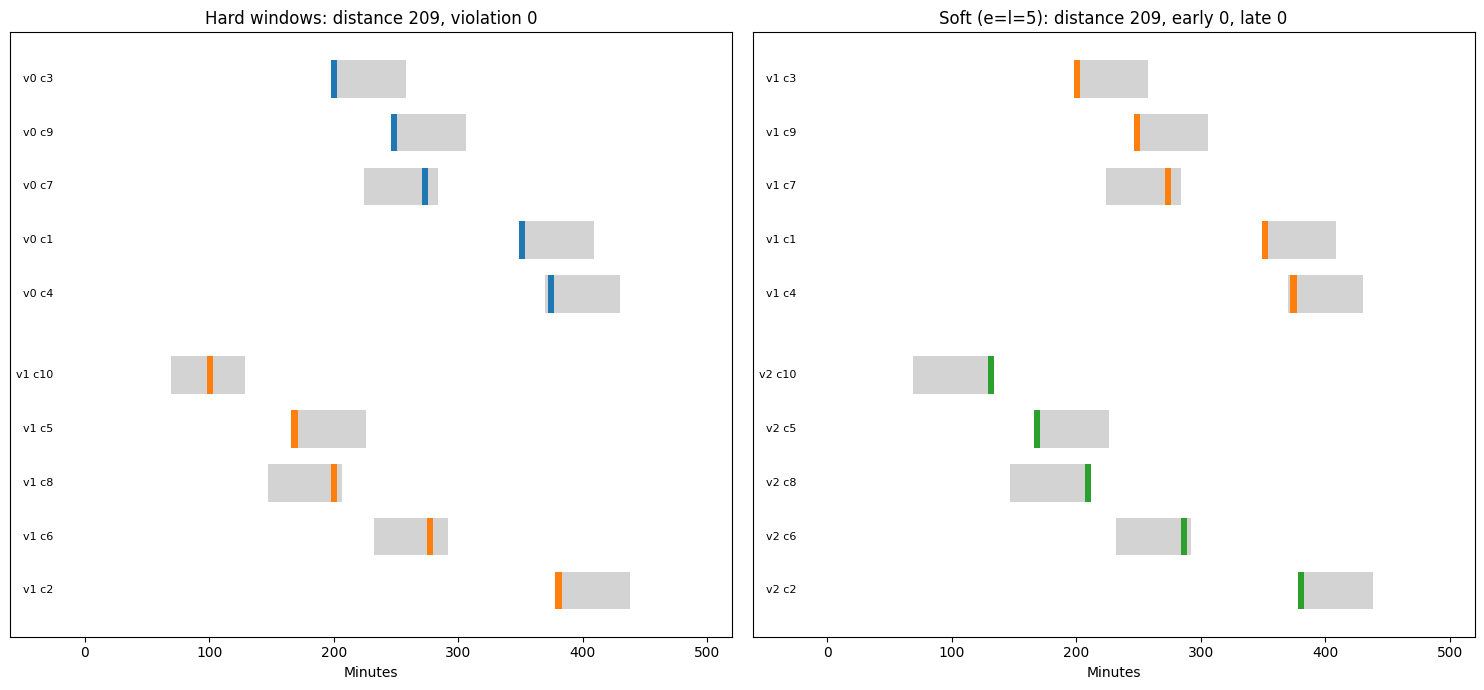

In [8]:
soft = solve_and_decompose(early_penalty=5, late_penalty=5)

def gantt(ax, arrivals, routes, label):
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, NUM_VEHICLES)))
    y = 0
    for v, route in enumerate(routes):
        for node in route:
            if node == DEPOT or node not in arrivals:
                continue
            a, b = windows[node]
            ax.barh(y, b - a, left=a, color="lightgrey", height=0.7, zorder=1)
            arr = arrivals[node]
            block_color = colors[v]
            if arr > b:
                block_color = "red"
            elif arr < a:
                block_color = "orange"
            ax.barh(y, SERVICE_TIME, left=arr, color=block_color, height=0.7, zorder=2)
            note = ""
            if arr > b:
                note = f"  +{arr - b}m late"
            elif arr < a:
                note = f"  -{a - arr}m early"
            ax.text(-25, y, f"v{v} c{node}", ha="right", va="center", fontsize=8)
            ax.text(arr + SERVICE_TIME + 4, y, note, va="center", fontsize=7, color="darkred")
            y += 1
        y += 0.5
    ax.set_yticks([]); ax.invert_yaxis()
    ax.set_xlim(-60, HORIZON + 40)
    ax.set_xlabel("Minutes")
    ax.set_title(label)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
gantt(ax1, hard["arrivals"], hard["routes"],
      f"Hard windows: distance {hard['distance']}, violation 0")
gantt(ax2, soft["arrivals"], soft["routes"],
      f"Soft (e=l=5): distance {soft['distance']}, "
      f"early {soft['early_min']}, late {soft['late_min']}")
plt.tight_layout(); plt.show()

## What's next

Soft windows are a special case of a much larger family: **soft constraints** in OR-Tools. Same machinery applies to:

- Soft *capacity* bounds (`AddDimensionWithVehicleCapacity` is hard, but you can build it manually with `SetCumulVarSoftUpperBound` on a capacity dimension if you want overflow allowed at a cost).
- Soft max-ride time for PDPTW.
- Soft route-distance limits to encourage shorter shifts.

## Promoting to `vrp_lib`

The next commit extends `vrp_lib.solve_vrptw` with `early_penalty` and `late_penalty` arguments. Backed by a test that checks lateness is bounded by what the penalty buys us.